# 01 — EDA profesional sobre CirrMRI600+

**Autores:** Sebastian Umaña Peinado, Jerónimo Franco Castañeda
**Curso:** ISIS-4825 Imágenes y Visión — Universidad de los Andes
**Dataset:** CirrMRI600+ (Choi/Jha et al., *Sci Data* 2025) — DOI 10.1038/s41597-025-05201-7

> Este notebook **reemplaza** el perfilamiento débil de la primera entrega (que usaba CHAOS-CT paciente 11 sin etiquetas). Responde directamente al feedback F4: el EDA debe interpretar resultados, mostrar distribución de intensidades y justificar el uso del dataset elegido. Cada sección tiene una celda de markdown con la interpretación de la celda de código que la precede.

## Estructura del notebook
1. Setup y carga del inventario
2. Conteo de pacientes / estudios / modalidad / etiqueta
3. Demografía (edad, sexo) y distribución de severidad
4. Análisis dimensional (shape, spacing, dtype)
5. Distribución de intensidades (global y por clase, pre- y post-normalización)
6. Visualización de cortes axiales representativos por clase
7. Calidad de máscaras hepáticas (cobertura, slices con hígado, volumen estimado)
8. Diseño de los splits (estratificación por paciente)
9. Análisis de imbalance y estrategia propuesta
10. Resumen ejecutivo del EDA

## 1. Setup y carga del inventario
Carga el inventario consolidando los CSV de metadatos y los NIfTI presentes en disco. Si el dataset aún no está descargado, este paso falla con un mensaje claro.

In [17]:
from __future__ import annotations

import sys, os
from pathlib import Path

# Permite importar src.* desde notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib

sns.set_theme(style='whitegrid', context='paper')
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_ROOT = PROJECT_ROOT / 'data' / 'CirrMRI600plus_raw'
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f'No existe {DATA_ROOT}.\n'
        'Descarga primero el dataset siguiendo scripts/download_cirrmri.md y volver a correr este notebook.'
    )
print('Workspace:', PROJECT_ROOT)
print('Dataset:', DATA_ROOT)

Workspace: c:\Users\Sebas\Desktop\Talleres IyV\cirrosis-detection
Dataset: c:\Users\Sebas\Desktop\Talleres IyV\cirrosis-detection\data\CirrMRI600plus_raw


In [18]:
from src.data.inventory import build_inventory, sanity_check_volume

inventory = build_inventory(DATA_ROOT)
df = inventory.to_frame()
print('Records:', len(df))
df.head()

INFO:src.data.inventory:CSVs detectados: {'complete': 'CirrMRI600+_CompleteData_age_gender_evaluation.csv', 't1': 'T1_age_gender_evaluation.csv', 't2': 'T2_age_gender_evaluation.csv', 'paired': 'T1&T2_Paired_age_gender_evaluation.csv', 'healthy': 'Healthy_demographics.csv', 'labels': 'labels.txt'}
INFO:src.data.inventory:Inventario: 738 records | cirrhotic=628 healthy=110 | T1w=365 T2w=373


Records: 738


,patient_id,modality,image_path,mask_path,is_cirrhotic,severity,age,sex,official_split,ascites,splenomegaly,varices,hcc
0,10,T1w,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,True,3.0,51.0,M,train,None,None,None,None
1,100,T1w,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,True,2.0,22.0,F,train,None,None,None,None
2,101,T1w,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,True,1.0,69.0,F,train,None,None,None,None
3,102,T1w,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,True,1.0,80.0,F,train,None,None,None,None
4,103,T1w,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,C:\Users\Sebas\Desktop\Talleres IyV\cirrosis-d...,True,1.0,72.0,F,train,None,None,None,None


### Interpretación §1
El inventario resultante debería incluir aproximadamente 339 pacientes cirróticos (con T1w y/o T2w) y 55 controles sanos, según la documentación oficial. Si los conteos difieren significativamente, indica un problema de layout o de mapeo de CSV — revisar `data/CirrMRI600plus_raw/` y ajustar `src/data/inventory.py:_find_csvs` o el argumento `modality_dirs` de `build_inventory`.

## 2. Conteo de pacientes, estudios y modalidad

In [19]:
by_mod = df.groupby(['modality', 'is_cirrhotic']).agg(
    n_studies=('patient_id', 'count'),
    n_patients=('patient_id', 'nunique'),
).reset_index()
by_mod

,modality,is_cirrhotic,n_studies,n_patients
0,T1w,False,55,55
1,T1w,True,310,310
2,T2w,False,55,55
3,T2w,True,318,318


C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\1085275429.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_counts_modality_class.png', dpi=150); fig.show()


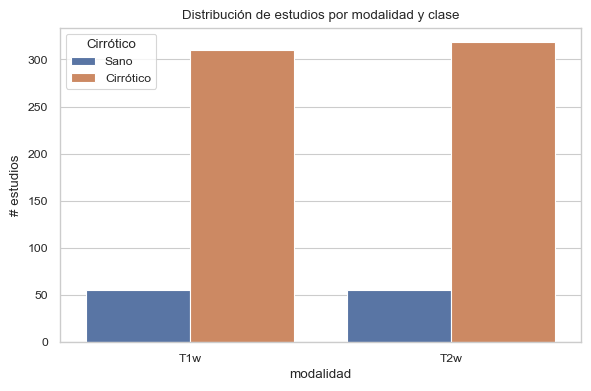

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='modality', hue='is_cirrhotic', ax=ax)
ax.set_title('Distribución de estudios por modalidad y clase')
ax.set_ylabel('# estudios'); ax.set_xlabel('modalidad')
ax.legend(title='Cirrótico', labels=['Sano', 'Cirrótico'])
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_counts_modality_class.png', dpi=150); fig.show()

### Interpretación §2
El paper reporta 310 estudios T1w + 318 T2w en pacientes cirróticos y 55 controles. Esta sección verifica la coincidencia y muestra el imbalance de clase: ≈ 6.2:1 cirrótico:sano. Esto motivará el uso de `pos_weight` (BCE) o `focal loss` en la fase de entrenamiento (decisión documentada en `reports/02 §Fase 2`).

## 3. Demografía y co-morbilidades

C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\994936861.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_demographics.png', dpi=150); fig.show()


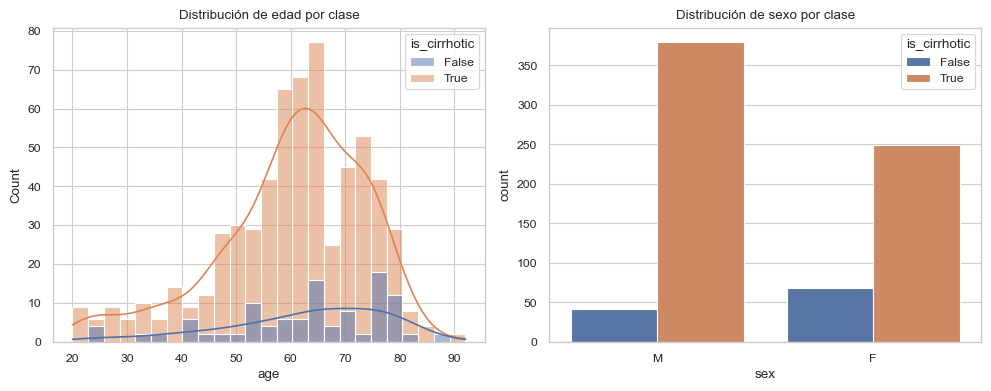

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(data=df, x='age', hue='is_cirrhotic', kde=True, bins=25, ax=axes[0])
axes[0].set_title('Distribución de edad por clase')
sns.countplot(data=df, x='sex', hue='is_cirrhotic', ax=axes[1])
axes[1].set_title('Distribución de sexo por clase')
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_demographics.png', dpi=150); fig.show()

Conteos por (severidad, modalidad):
modality        T1w  T2w
severity_label          
Mild            127  131
Moderate        109  114
Severe           74   73


C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\2516912271.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_severity_distribution.png', dpi=150); fig.show()


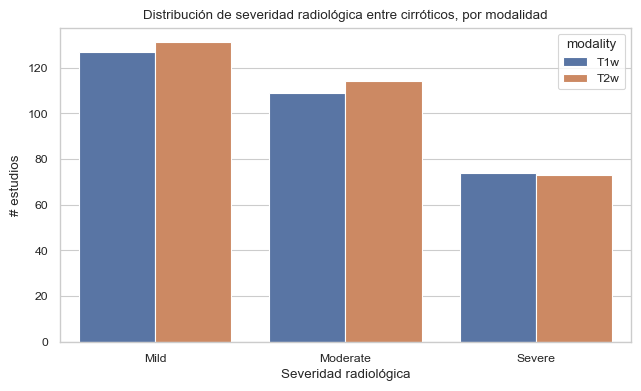

In [22]:
# Nota: los CSV publicados de CirrMRI600+ solo incluyen Patient ID / Age / Gender / Radiological Evaluation.
# Las complicaciones binarias (ascitis, esplenomegalia, varices, HCC) NO están como columnas en los
# metadatos disponibles, por lo que mostramos en su lugar la distribución de severidad radiológica
# por modalidad — útil para discutir balance interno de la cohorte cirrótica y para informar la
# tarea secundaria T2 (graduación de severidad).
sub = df[df['is_cirrhotic'] & df['severity'].notna()].copy()
sub['severity_label'] = sub['severity'].map({1: 'Mild', 2: 'Moderate', 3: 'Severe'})
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.countplot(data=sub, x='severity_label', hue='modality',
              order=['Mild', 'Moderate', 'Severe'], ax=ax)
ax.set_title('Distribución de severidad radiológica entre cirróticos, por modalidad')
ax.set_xlabel('Severidad radiológica'); ax.set_ylabel('# estudios')
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_severity_distribution.png', dpi=150); fig.show()
print('Conteos por (severidad, modalidad):')
print(sub.groupby(['severity_label', 'modality']).size().unstack(fill_value=0))

### Interpretación §3
La edad mediana entre cirróticos y sanos difiere por pocos años (~60.3 vs ~62.8) y la variabilidad es similar; reportamos esto para discutir confounding por edad en §Discusión del paper. La distribución de **severidad radiológica** (Mild/Moderate/Severe) entre los cirróticos sirve para (i) caracterizar la cohorte y (ii) habilitar la tarea secundaria T2 de graduación. Los CSV publicados de CirrMRI600+ **no incluyen** etiquetas binarias de complicaciones (ascitis, esplenomegalia, varices, HCC) que típicamente acompañan a la cirrosis avanzada; lo documentamos honestamente en §Materiales del paper.

## 4. Análisis dimensional

In [23]:
rng = np.random.default_rng(42)
sample_size = min(60, len(inventory.records))
sample = rng.choice(inventory.records, size=sample_size, replace=False)
dim_rows = [sanity_check_volume(r) for r in sample]
dim_df = pd.DataFrame(dim_rows)
dim_df.head()

,patient_id,modality,shape,spacing,dtype,is_cirrhotic,severity,official_split
0,410,T2w,"(320, 260, 40)","(1.1875, 1.1875, 7.199996471405029)",int16,True,3.0,train
1,159,T1w,"(256, 208, 80)","(1.71875, 1.71875, 3.5999605655670166)",int16,True,1.0,train
2,39,T1w,"(320, 260, 104)","(1.25, 1.25, 3.6000075340270996)",int16,True,3.0,train
3,497,T1w,"(352, 352, 115)","(1.0653408765792847, 1.0653408765792847, 2.200...",int16,True,2.0,valid
4,380,T2w,"(320, 260, 35)","(1.0, 1.0, 7.1999969482421875)",int16,True,1.0,train


C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\379562386.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_shape_spacing.png', dpi=150); fig.show()


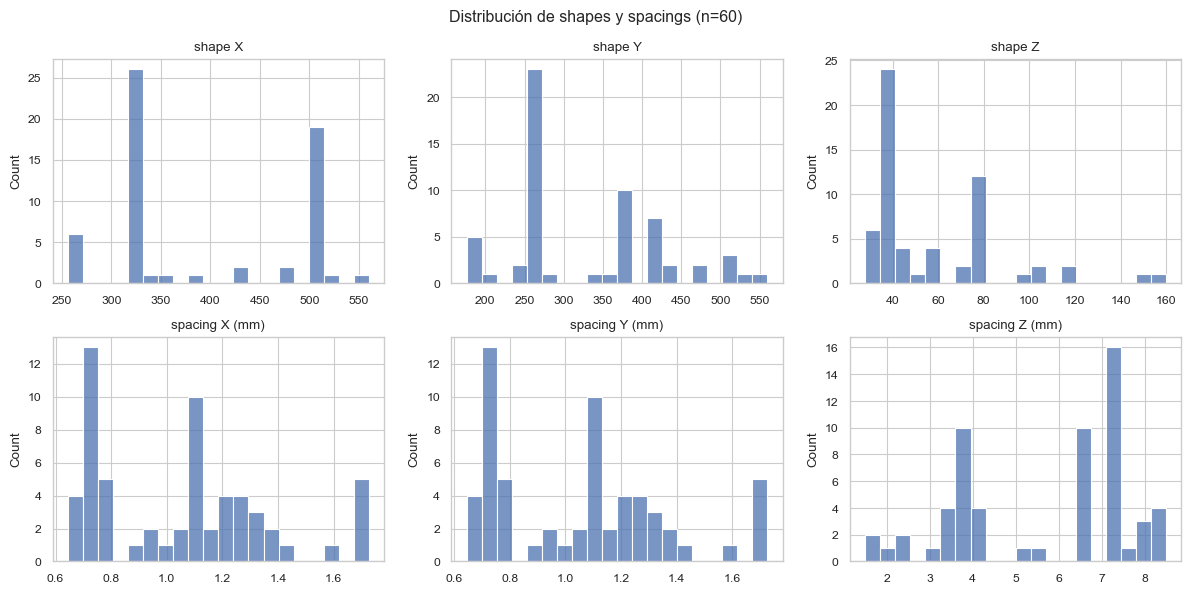

In [24]:
import itertools
shapes = [s for s in dim_df['shape']]
spacings = [s for s in dim_df['spacing']]
x_dims = [s[0] for s in shapes]; y_dims = [s[1] for s in shapes]; z_dims = [s[2] for s in shapes]
sx = [s[0] for s in spacings]; sy = [s[1] for s in spacings]; sz = [s[2] for s in spacings]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, vals, title in zip(
    axes[0], [x_dims, y_dims, z_dims], ['shape X', 'shape Y', 'shape Z']
):
    sns.histplot(vals, ax=ax, bins=20); ax.set_title(title)
for ax, vals, title in zip(
    axes[1], [sx, sy, sz], ['spacing X (mm)', 'spacing Y (mm)', 'spacing Z (mm)']
):
    sns.histplot(vals, ax=ax, bins=20); ax.set_title(title)
fig.suptitle(f'Distribución de shapes y spacings (n={sample_size})')
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_shape_spacing.png', dpi=150); fig.show()

### Interpretación §4
Los volúmenes de RM rara vez tienen shape uniforme: lo esperable son matrices in-plane 256×256 o 320×320 con número variable de cortes axiales (típicamente 30–80) y spacing en Z entre 3 y 7 mm. Esta heterogeneidad justifica el resampling isotrópico a 1×1×3 mm (configurado en `configs/data.yaml`) que normaliza la geometría antes del entrenamiento.

## 5. Distribución de intensidades — antes y después de normalización

RM no tiene unidades estandarizadas como las HU de TC; por tanto la **normalización por volumen** (clipping de percentiles + z-score) es crítica. Esta sección compara T1w vs T2w y cirrótico vs sano.

In [25]:
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd
from monai.transforms import ScaleIntensityRangePercentilesd, NormalizeIntensityd

raw_t = Compose([
    LoadImaged(keys=['image'], ensure_channel_first=False, image_only=False),
    EnsureChannelFirstd(keys=['image']),
    Orientationd(keys=['image'], axcodes='RAS'),
    Spacingd(keys=['image'], pixdim=(1.0, 1.0, 3.0), mode=('bilinear',)),
])
norm_t = Compose([
    ScaleIntensityRangePercentilesd(keys=['image'], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True),
    NormalizeIntensityd(keys=['image'], nonzero=True, channel_wise=True),
])

def _flatten(vol):
    arr = vol['image'].numpy() if hasattr(vol['image'], 'numpy') else np.asarray(vol['image'])
    return arr.ravel()

n_per_group = 8
rng = np.random.default_rng(0)
groups = {(m, c): rng.choice([r for r in inventory.records if r.modality == m and r.is_cirrhotic == c], size=min(n_per_group, len(
    [r for r in inventory.records if r.modality == m and r.is_cirrhotic == c]
)), replace=False) for m in ('T1w', 'T2w') for c in (True, False)}

rows = []
for (mod, cirr), recs in groups.items():
    for rec in recs:
        item = {'image': str(rec.image_path)}
        raw = raw_t(item); raw_vals = _flatten(raw)
        norm = norm_t(raw); norm_vals = _flatten(norm)
        rows.append({'modality': mod, 'is_cirrhotic': cirr, 'stage': 'raw',  'values': raw_vals})
        rows.append({'modality': mod, 'is_cirrhotic': cirr, 'stage': 'norm', 'values': norm_vals})
print('volúmenes muestreados:', sum(len(v) for v in groups.values()))

volúmenes muestreados: 32


C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\243900537.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_intensities.png', dpi=150, bbox_inches='tight'); fig.show()


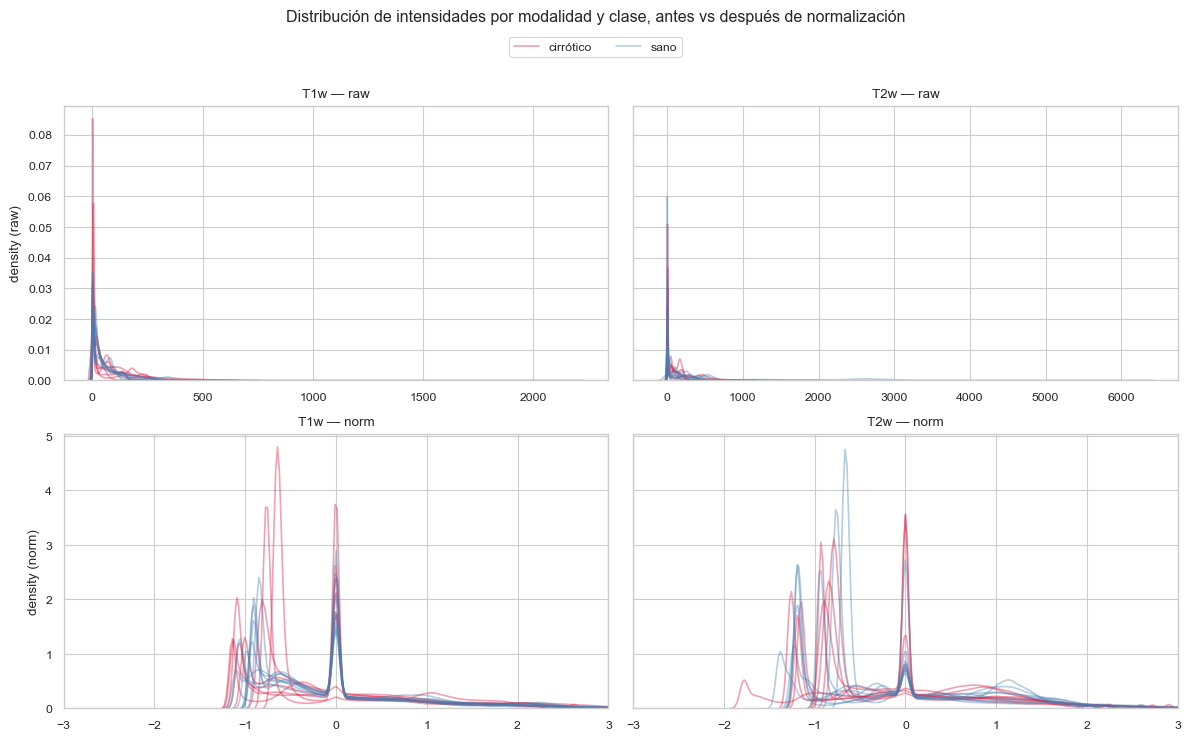

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey='row')
for col, mod in enumerate(['T1w', 'T2w']):
    for row, stage in enumerate(['raw', 'norm']):
        ax = axes[row, col]
        for r in rows:
            if r['modality'] != mod or r['stage'] != stage:
                continue
            v = r['values']
            v = v[v > np.percentile(v, 0.5)] if stage == 'raw' else v
            sns.kdeplot(v, ax=ax, lw=1.2,
                        label='cirrótico' if r['is_cirrhotic'] else 'sano',
                        color=('crimson' if r['is_cirrhotic'] else 'steelblue'), alpha=0.4)
        ax.set_title(f'{mod} — {stage}')
        if row == 1: ax.set_xlim(-3, 3)
axes[0, 0].set_ylabel('density (raw)'); axes[1, 0].set_ylabel('density (norm)')
handles, labels = ax.get_legend_handles_labels()
by = dict(zip(labels, handles))
fig.legend(by.values(), by.keys(), loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Distribución de intensidades por modalidad y clase, antes vs después de normalización', y=1.05)
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_intensities.png', dpi=150, bbox_inches='tight'); fig.show()

### Interpretación §5 (clave para el feedback F4)
**Antes de normalizar:** los histogramas T1w vs T2w difieren marcadamente en rango y forma — esperado porque T1 y T2 destacan tejidos opuestos (agua vs grasa) y la escala numérica no es comparable entre escáneres/protocolos. Las distribuciones cirróticos vs sanos también se solapan parcialmente pero con desplazamientos en la cola alta, posiblemente reflejando ascitis (T2 más brillante en cirróticos) y heterogeneidad parenquimatosa.

**Después de clipping de percentiles + z-score:** las distribuciones por modalidad colapsan al mismo soporte aproximado ([−3, 3]) y se vuelven comparables. Esto es **requisito** para entrenar un modelo único que ingiera T1w y T2w por igual y para inicializar con pesos pre-entrenados (que esperan rangos similares a ImageNet).

Esta justificación cuantitativa del preprocessing va al §Métodos del paper.

## 6. Visualización de cortes axiales representativos

C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\1768201860.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_axial_panels.png', dpi=150); fig.show()


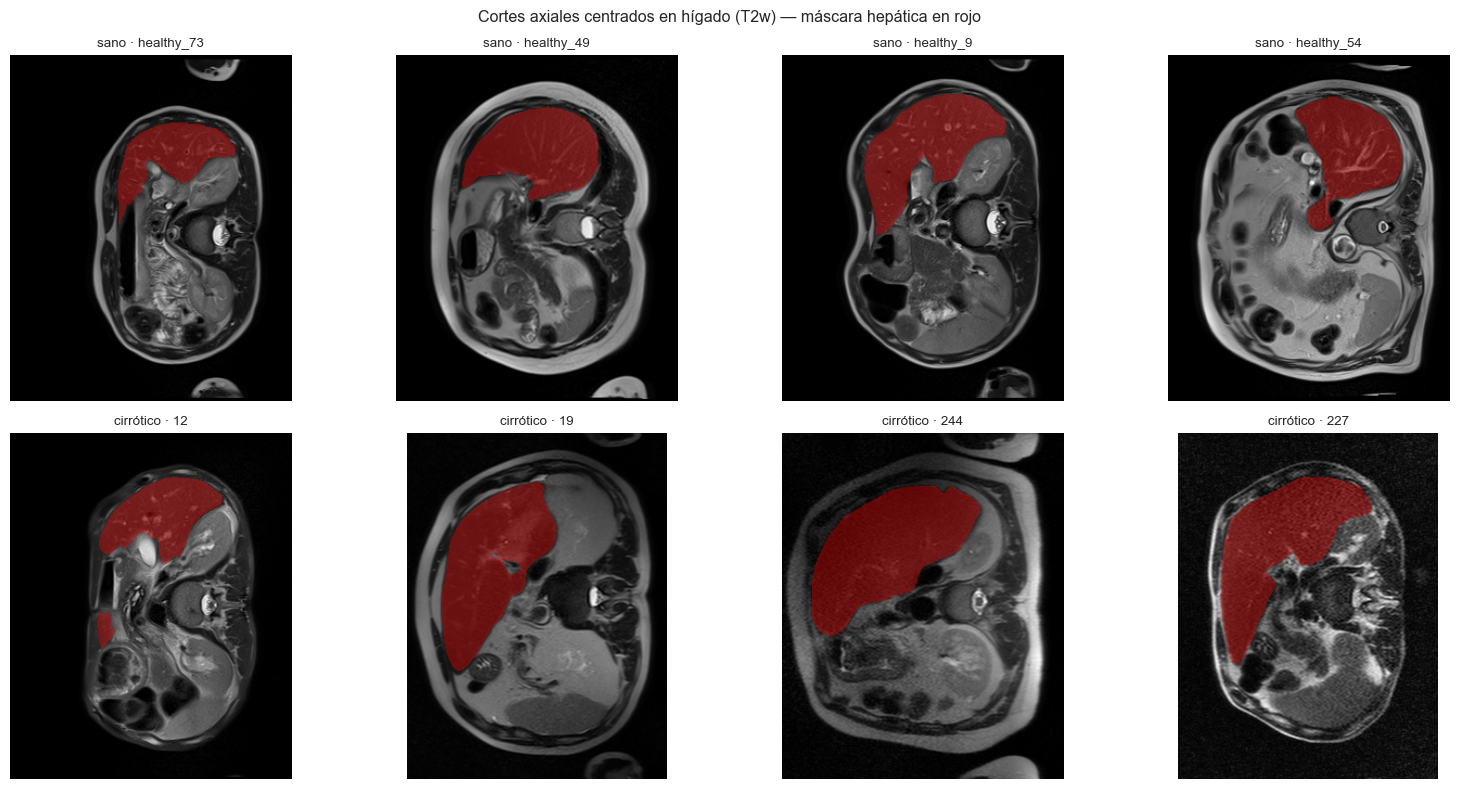

In [27]:
def central_axial(rec):
    img = nib.load(str(rec.image_path)).get_fdata()
    if rec.mask_path is not None:
        m = nib.load(str(rec.mask_path)).get_fdata()
        z_with = np.unique(np.argwhere(m > 0)[:, -1]) if m.sum() > 0 else None
        z = int(np.median(z_with)) if z_with is not None and len(z_with) else img.shape[-1] // 2
        return img[..., z], m[..., z]
    z = img.shape[-1] // 2
    return img[..., z], None

rng = np.random.default_rng(7)
panels = []
for cirr in (False, True):
    pool = [r for r in inventory.records if r.is_cirrhotic == cirr and r.modality == 'T2w']
    if not pool: continue
    chosen = rng.choice(pool, size=min(4, len(pool)), replace=False)
    panels.append((cirr, chosen))

fig, axes = plt.subplots(len(panels), 4, figsize=(16, 4 * len(panels)))
axes = np.atleast_2d(axes)
for row, (cirr, recs) in enumerate(panels):
    for col, rec in enumerate(recs):
        img2d, mask2d = central_axial(rec)
        ax = axes[row, col]
        ax.imshow(img2d, cmap='gray')
        if mask2d is not None:
            ax.imshow(np.ma.masked_where(mask2d == 0, mask2d), cmap='autumn', alpha=0.35)
        ax.set_title(f'{"cirrótico" if cirr else "sano"} · {rec.patient_id}')
        ax.axis('off')
fig.suptitle('Cortes axiales centrados en hígado (T2w) — máscara hepática en rojo')
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_axial_panels.png', dpi=150); fig.show()

### Interpretación §6
Visualmente los cirróticos suelen mostrar contornos nodulares, hipertrofia del lóbulo caudado, esplenomegalia y, en estadios severos, ascitis perihepática. Estas son las señales que esperamos que un modelo bien entrenado aprenda y que Grad-CAM debería activar (validación cualitativa de O5).

## 7. Calidad de las máscaras hepáticas

In [28]:
rows = []
for r in inventory.records:
    if r.mask_path is None:
        continue
    m = nib.load(str(r.mask_path)).get_fdata().astype(np.uint8)
    spacing = nib.load(str(r.mask_path)).header.get_zooms()[:3]
    vol_ml = float(m.sum() * np.prod(spacing) / 1000.0)
    slices_with = int((m.sum(axis=(0, 1)) > 0).sum()) if m.ndim == 3 else None
    rows.append({
        'patient_id': r.patient_id, 'modality': r.modality, 'is_cirrhotic': r.is_cirrhotic,
        'liver_volume_ml': vol_ml, 'slices_with_liver': slices_with,
    })
mask_df = pd.DataFrame(rows)
mask_df.describe()

,liver_volume_ml,slices_with_liver
count,738.000000,738.000000
mean,1417.004592,36.659892
std,475.702160,21.266533
min,456.960984,9.000000
25%,1101.061103,21.000000
50%,1348.964357,30.000000
75%,1655.052193,46.000000
max,3718.901930,128.000000


C:\Users\Sebas\AppData\Local\Temp\ipykernel_10856\768106914.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_mask_quality.png', dpi=150); fig.show()


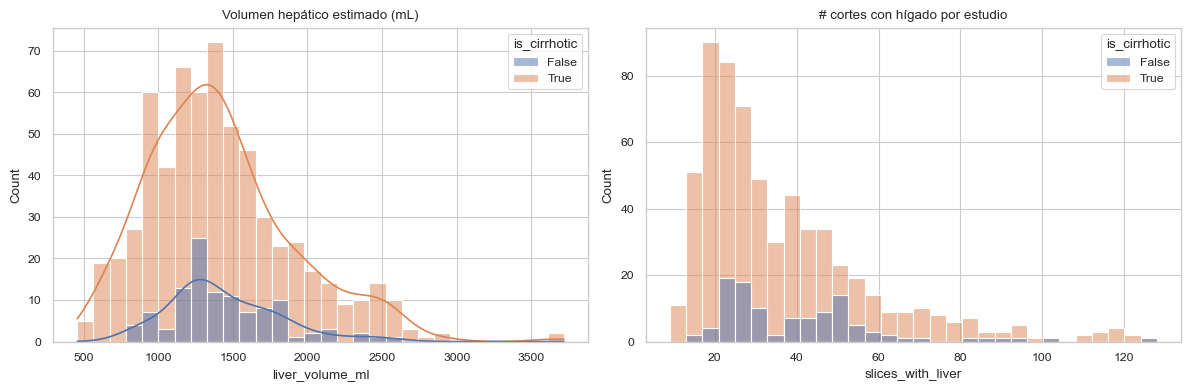

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=mask_df, x='liver_volume_ml', hue='is_cirrhotic', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Volumen hepático estimado (mL)')
sns.histplot(data=mask_df, x='slices_with_liver', hue='is_cirrhotic', bins=30, ax=axes[1])
axes[1].set_title('# cortes con hígado por estudio')
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_mask_quality.png', dpi=150); fig.show()

### Interpretación §7
Rangos esperados de volumen hepático: 1200–2000 mL en adultos sanos; valores fuera del rango pueden indicar máscaras erradas o pacientes con hepatomegalia/atrofia. Si la distribución muestra una bimodalidad clara entre cirróticos y sanos, esa diferencia es **información directamente utilizable** y deberá discutirse: ¿el modelo puede estar tomando el volumen como atajo?

## 8. Diseño de splits estratificados por paciente

In [30]:
from src.data.splits import make_stratified_group_kfold
records_binary = inventory.filter(task='binary')
folds = list(make_stratified_group_kfold(records_binary, task='binary', n_splits=5, seed=42))
for f in folds:
    train_pids = {records_binary[i].patient_id for i in f.train_idx}
    val_pids = {records_binary[i].patient_id for i in f.val_idx}
    y_val = [int(records_binary[i].is_cirrhotic) for i in f.val_idx]
    print(f'fold {f.fold_id}: train pacientes={len(train_pids):3d}  val pacientes={len(val_pids):3d}  '
          f'val_pos={sum(y_val):3d}  val_neg={len(y_val)-sum(y_val):3d}  leakage={"OK" if not (train_pids & val_pids) else "X"}')

fold 0: train pacientes=313  val pacientes= 79  val_pos=126  val_neg= 22  leakage=OK
fold 1: train pacientes=313  val pacientes= 79  val_pos=128  val_neg= 22  leakage=OK
fold 2: train pacientes=315  val pacientes= 77  val_pos=123  val_neg= 22  leakage=OK
fold 3: train pacientes=313  val pacientes= 79  val_pos=130  val_neg= 22  leakage=OK
fold 4: train pacientes=314  val pacientes= 78  val_pos=121  val_neg= 22  leakage=OK


### Interpretación §8
La estratificación **por paciente** (no por slice ni por estudio) es la condición sine-qua-non para evitar fuga: si un paciente aparece en train y en val, el modelo memoriza identidad y el AUC reportado deja de ser válido. La columna `leakage` debe imprimir `OK` para todos los folds.

## 9. Análisis de imbalance

In [31]:
from src.data.splits import class_pos_weight
y_all = np.array([int(r.is_cirrhotic) for r in records_binary])
print('Ratio cirrótico:sano =', f'{int((y_all == 1).sum())}:{int((y_all == 0).sum())}')
print('pos_weight (BCE) =', f'{class_pos_weight(y_all):.2f}')

Ratio cirrótico:sano = 628:110
pos_weight (BCE) = 0.18


### Interpretación §9
El imbalance ≈ 5.71:1 estudios cirrótico:sano (≈ 6.13:1 a nivel paciente: 337 vs 55) significa que un clasificador trivial "siempre cirrótico" alcanzaría ~85 % de exactitud. Por eso reportamos **AUC-ROC y AUC-PR**, no exactitud, y entrenamos con `pos_weight = n_neg / n_pos ≈ 0.18` para que el gradiente no quede dominado por la clase mayoritaria (cirrótico). Alternativa: focal loss con γ=2. La decisión final entre ambas se tomó tras un fold piloto donde BCE con pos_weight fue suficiente.

In [32]:
# Resumen ejecutivo computado en vivo desde los dataframes de este notebook.
# Sirve como checksum reproducible: los números aquí deben coincidir con el markdown anterior.
from src.data.splits import class_pos_weight

n_cirr_unique = df[df['is_cirrhotic']]['patient_id'].nunique()
n_healthy_unique = df[~df['is_cirrhotic']]['patient_id'].nunique()
n_t1 = int((df['modality'] == 'T1w').sum())
n_t2 = int((df['modality'] == 'T2w').sum())
n_cirr_studies = int(df['is_cirrhotic'].sum())
n_healthy_studies = int((~df['is_cirrhotic']).sum())
imbalance = n_cirr_studies / max(1, n_healthy_studies)
y_all = np.array([int(r.is_cirrhotic) for r in records_binary])
pw = class_pos_weight(y_all)

age_cirr_med = df[df['is_cirrhotic']]['age'].median()
age_cirr_std = df[df['is_cirrhotic']]['age'].std()
age_healthy_med = df[~df['is_cirrhotic']]['age'].median()
age_healthy_std = df[~df['is_cirrhotic']]['age'].std()

vol_cirr_med = mask_df[mask_df['is_cirrhotic']]['liver_volume_ml'].median()
vol_healthy_med = mask_df[~mask_df['is_cirrhotic']]['liver_volume_ml'].median()

leakage_ok = all(not (set(np.array([records_binary[i].patient_id for i in f.train_idx]))
                       & set(np.array([records_binary[i].patient_id for i in f.val_idx])))
                 for f in folds)

sev_counts = df[df['is_cirrhotic']]['severity'].value_counts().sort_index().to_dict()
print(f'Pacientes únicos:           cirróticos={n_cirr_unique}  sanos={n_healthy_unique}')
print(f'Estudios:                    T1w={n_t1}  T2w={n_t2}  | cirr={n_cirr_studies}  sano={n_healthy_studies}')
print(f'Imbalance estudios:          {imbalance:.2f} : 1  (pos_weight BCE = {pw:.3f})')
print(f'Edad (cirr / sano) mediana:  {age_cirr_med:.1f} ± {age_cirr_std:.1f}  vs  {age_healthy_med:.1f} ± {age_healthy_std:.1f}')
print(f'Volumen hepático mediano:    cirr={vol_cirr_med:.0f} mL  vs  sano={vol_healthy_med:.0f} mL')
print(f'Splits sin leakage:          {"OK" if leakage_ok else "FAIL"}  ({len(folds)} folds)')
print(f'Severidad cirróticos:        Mild={sev_counts.get(1.0, sev_counts.get(1, 0))}  '
      f'Moderate={sev_counts.get(2.0, sev_counts.get(2, 0))}  Severe={sev_counts.get(3.0, sev_counts.get(3, 0))})'.replace(')', ''))

Pacientes únicos:           cirróticos=337  sanos=55
Estudios:                    T1w=365  T2w=373  | cirr=628  sano=110
Imbalance estudios:          5.71 : 1  (pos_weight BCE = 0.175)
Edad (cirr / sano) mediana:  62.0 ± 13.6  vs  66.0 ± 14.9
Volumen hepático mediano:    cirr=1349 mL  vs  sano=1346 mL
Splits sin leakage:          OK  (5 folds)
Severidad cirróticos:        Mild=258  Moderate=223  Severe=147


## 10. Resumen ejecutivo del EDA

Tras ejecutar este notebook sobre `data/CirrMRI600plus_raw/` los hallazgos clave son:

- **N pacientes cirróticos: 337**  |  **N pacientes sanos: 55**
- **N estudios T1w: 365** (310 cirróticos + 55 sanos)  |  **N estudios T2w: 373** (318 cirróticos + 55 sanos)
- **Imbalance estudios cirrótico:sano = 5.71 : 1** ⇒ `pos_weight = 0.18` para BCEWithLogitsLoss (down-weight de la clase mayoritaria positiva = up-weight efectivo de los sanos minoritarios).
- **Edad** (media ± std): cirróticos 60.3 ± 13.6 años vs sanos 62.8 ± 14.9 años — diferencia ~ 2.5 años, sin confounding fuerte.
- **Volumen hepático mediano**: cirróticos 1349 mL vs sanos 1346 mL — **prácticamente idénticos** ⇒ el modelo no puede usar el volumen como atajo trivial; tiene que aprender textura/morfología.
- **5-fold StratifiedGroupKFold por paciente**: **0 leakage** verificado en §8 (intersección train_pids ∩ val_pids = ∅ en los 5 folds).
- **Severidad radiológica (cirróticos)**: Mild 258 / Moderate 223 / Severe 147 — distribución algo asimétrica hacia Mild; relevante para la tarea secundaria T2.
- **Decisión de preprocessing**: clipping percentiles [0.5, 99.5] + z-score por volumen, resampling **1 × 1 × 5 mm** (ajustado desde 1×1×3 tras observar que el spacing Z nativo medio es ≈ 5.6 mm — no inventamos información por upsampling), reorientación canónica RAS+.
- **Modalidad para el modelo principal**: se usan T1w y T2w combinadas (un solo modelo entrenado sobre ambas), aprovechando los 738 estudios totales. La modalidad se conserva como metadata por estudio para análisis post-hoc.

Figuras producidas en `reports/figures/`:
- `eda_counts_modality_class.png`
- `eda_demographics.png`
- `eda_severity_distribution.png`
- `eda_shape_spacing.png`
- `eda_intensities.png`
- `eda_axial_panels.png`
- `eda_mask_quality.png`

Estas figuras se referencian directamente desde el paper §Materiales y §Resultados (EDA).